In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from data import BankingDataModule
from model import BankingClassifier

W0814 19:09:57.051468 8752 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [5]:
TRAIN_PATH = r"E:\Dl(learn)\Bannking_77\train.csv"
TEST_PATH = r"E:\Dl(learn)\Bannking_77\test.csv"

MODEL_PATH = r"E:\Dl(learn)\hugging face (parctise)\distilbert-base"

CHECKPOINT_PATH =(
    r"E:\Dl(learn)\Bannking_77\checkpoints\banking 77.ckpt"

)

In [6]:
data = BankingDataModule(
    train_path=TRAIN_PATH,
    test_path=TEST_PATH,
    batch_size=32,
)

data.setup(stage="test")

test_loader = data.test_dataloader()

class_names = data.label_encoder.classes_

print("Number of classes:", len(class_names))
print("Test samples:", len(data.test_dataset))


Number of classes: 77
Test samples: 3080


In [7]:
model = BankingClassifier.load_from_checkpoint(
    CHECKPOINT_PATH,
    model_name=MODEL_PATH,
    num_classes=77,
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)
model.eval()

print("Device:", device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: E:\Dl(learn)\hugging face (parctise)\distilbert-base
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Device: cuda


In [8]:
all_preds = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        preds = torch.argmax(
            logits,
            dim=1,
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

print("Predictions:", len(y_pred))

Predictions: 3080


In [9]:
accuracy = accuracy_score(
    y_true,
    y_pred,
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0,
)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        macro_f1,
        weighted_f1,
    ],
})

results

,Metric,Score
0,Accuracy,0.930519
1,Macro Precision,0.932926
2,Macro Recall,0.930519
3,Macro F1,0.930490
4,Weighted F1,0.930490


In [10]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T

report_df.head()

,precision,recall,f1-score,support
Refund_not_showing_up,0.973684,0.925,0.948718,40.0
activate_my_card,1.000000,0.975,0.987342,40.0
age_limit,1.000000,1.000,1.000000,40.0
apple_pay_or_google_pay,1.000000,1.000,1.000000,40.0
atm_support,0.975610,1.000,0.987654,40.0


In [11]:
class_report = report_df.iloc[:-3].copy()

worst_classes = (
    class_report
    .sort_values("f1-score")
    [["precision", "recall", "f1-score", "support"]]
    .head(15)
)

worst_classes

,precision,recall,f1-score,support
pending_transfer,0.882353,0.750,0.810811,40.0
declined_transfer,0.965517,0.700,0.811594,40.0
balance_not_updated_after_bank_transfer,0.804878,0.825,0.814815,40.0
topping_up_by_card,0.868421,0.825,0.846154,40.0
top_up_failed,0.800000,0.900,0.847059,40.0
lost_or_stolen_card,0.833333,0.875,0.853659,40.0
direct_debit_payment_not_recognised,0.837209,0.900,0.867470,40.0
failed_transfer,0.837209,0.900,0.867470,40.0
transfer_into_account,0.894737,0.850,0.871795,40.0
compromised_card,0.875000,0.875,0.875000,40.0


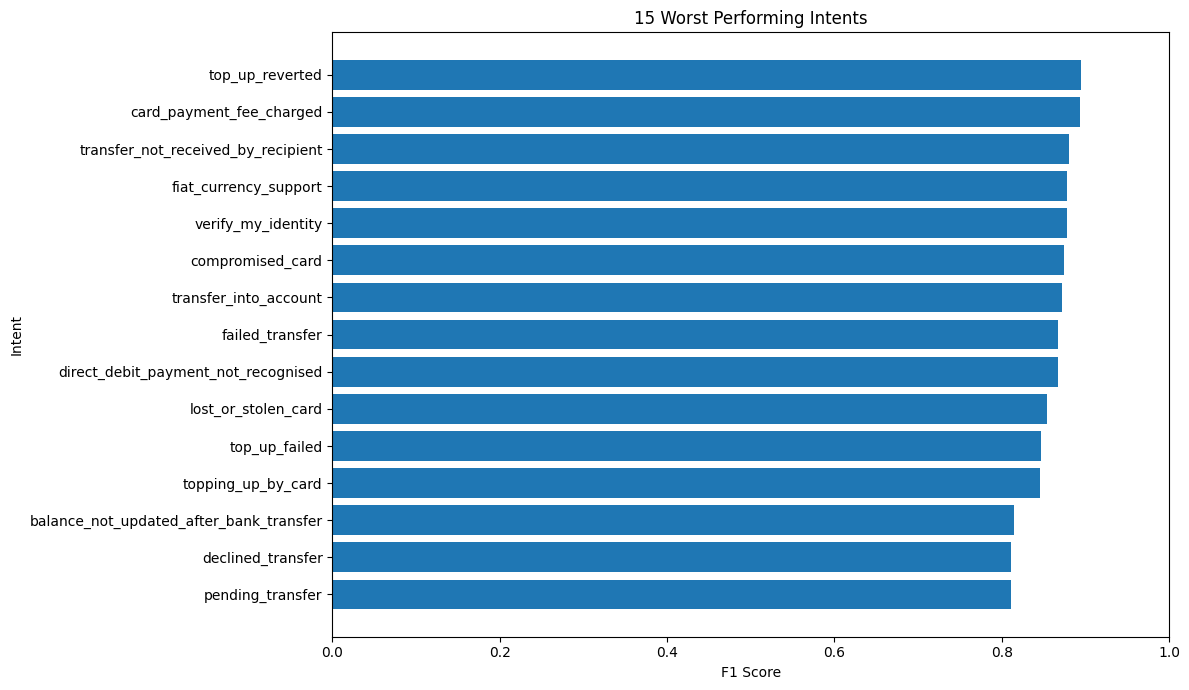

In [12]:
plt.figure(figsize=(12, 7))

plt.barh(
    worst_classes.index,
    worst_classes["f1-score"],
)

plt.xlabel("F1 Score")
plt.ylabel("Intent")
plt.title("15 Worst Performing Intents")

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [13]:
best_classes = (
    class_report
    .sort_values("f1-score", ascending=False)
    [["precision", "recall", "f1-score"]]
    .head(15)
)

best_classes

,precision,recall,f1-score
verify_top_up,1.000000,1.000,1.000000
age_limit,1.000000,1.000,1.000000
apple_pay_or_google_pay,1.000000,1.000,1.000000
passcode_forgotten,1.000000,1.000,1.000000
verify_source_of_funds,1.000000,1.000,1.000000
terminate_account,1.000000,1.000,1.000000
atm_support,0.975610,1.000,0.987654
edit_personal_details,0.975610,1.000,0.987654
card_about_to_expire,1.000000,0.975,0.987342
balance_not_updated_after_cheque_or_cash_deposit,1.000000,0.975,0.987342


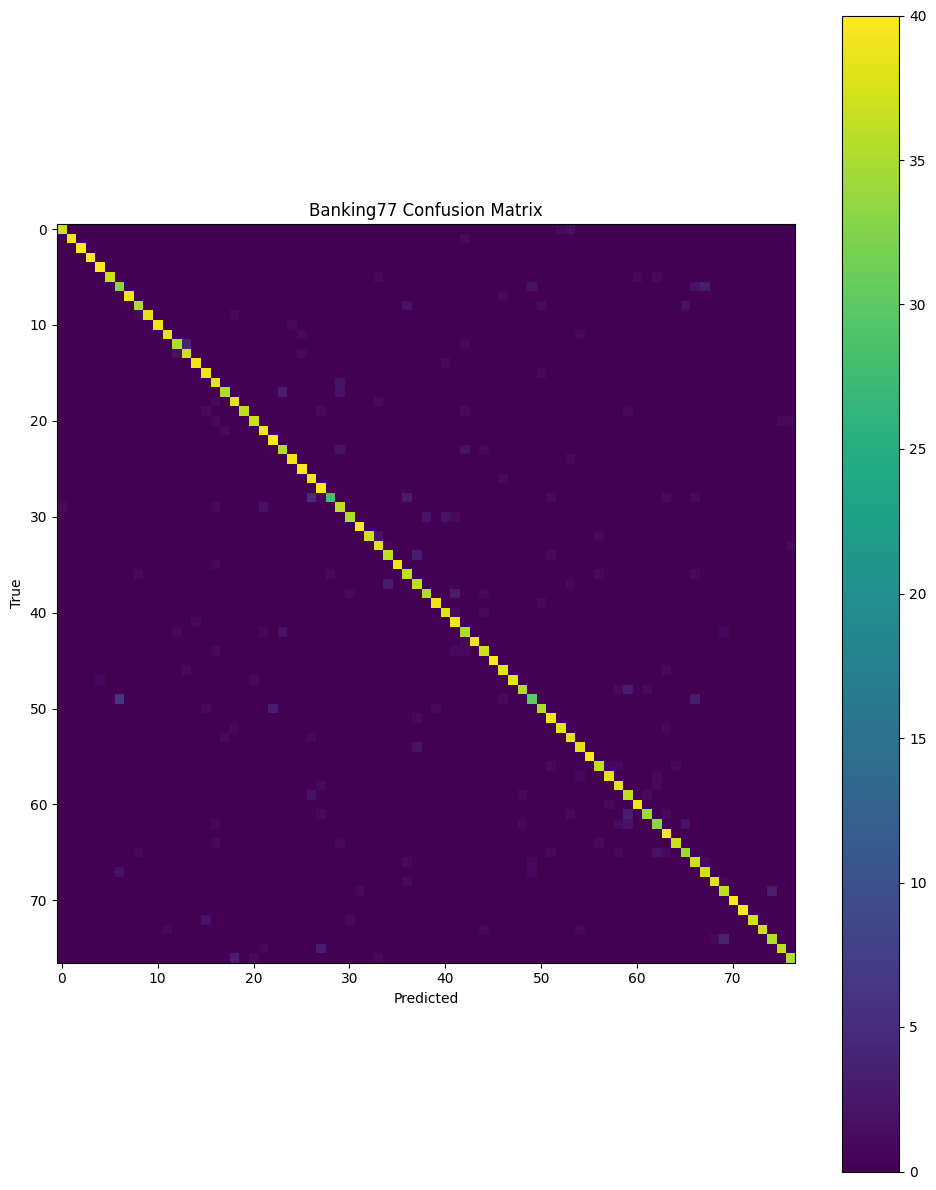

In [17]:
cm = confusion_matrix(
    y_true,
    y_pred,
)

plt.figure(figsize=(10, 12))

plt.imshow(cm)

plt.title("Banking77 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.colorbar()

plt.tight_layout()
plt.show()

In [15]:
cm_no_diag = cm.copy()

np.fill_diagonal(
    cm_no_diag,
    0,
)

confusions = []

for i in range(len(class_names)):

    for j in range(len(class_names)):

        if cm_no_diag[i, j] > 0:

            confusions.append({
                "count": cm_no_diag[i, j],
                "true": class_names[i],
                "predicted": class_names[j],
            })

confusion_df = pd.DataFrame(
    confusions
).sort_values(
    "count",
    ascending=False,
)

confusion_df.head(20)

,count,true,predicted
89,6,pending_transfer,balance_not_updated_after_bank_transfer
42,5,declined_transfer,declined_card_payment
18,4,card_arrival,card_delivery_estimate
145,4,why_verify_identity,verify_my_identity
93,3,pin_blocked,change_pin
87,3,pending_top_up,top_up_failed
44,3,declined_transfer,failed_transfer
65,3,fiat_currency_support,exchange_via_app
58,3,exchange_via_app,fiat_currency_support
91,3,pending_transfer,transfer_not_received_by_recipient


In [16]:
baseline = {
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
}

baseline

{'accuracy': 0.9305194805194805,
 'macro_f1': 0.9304903288188426,
 'weighted_f1': 0.9304903288188427}